# Student Dropout Prediction
High dropout rates are a cause for concern in all levels of education, however it is much more common in post-secondary education such as college and university. These dropout rates are a cause for concern as they signal social, structural, and education problems that extend beyond individual students and reflect broader issues within the post-secondary system. These rates indicate barriers such as financial strain, lack of academic preparation in childhood, inadequate support system, and mental health challenges. As a result of these factors, students who drop out may face employment issues, lack of good opportunities, and lower lifetime earnings, while institutions and soceity face economic losses, a decrease in talent and productivity of the workforce, and inequality. 

This project applies tree-based classification methods to predict whether a student will continue enrollment, graduate, or drop out based on various factors pertaining demographic, academic, and socioeconomic features. Examples of factors that are examined in this project are admission grades, marital status, nationality, GDP, etc. 

The dataset that I used for this project is available at kaggle (https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success) and it contains 4,424 records of students spread out across 8 different academic programs demonstrating great flexibility spanning through different circumstances. 

Through the use of the interpretation of my data analysis, I will leverage my data to draw conclusions and come up with solutions of how institutions can use my prediction models to reduce the rate of dropouts. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from ISLP import load_data

from scipy import stats
from scipy.stats import norm, t, binom, expon, beta

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from time import time
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold, RepeatedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')


# Data Introduction
Below we can see through our sample data introduction that the amount of student dropouts is a clear cause for concern as the amount of students that dropped out in our dataset is near 1500, whereas the amount of students that completed their degree and graduated was just over 2200. The concerning amount of student dropouts is the basis for the motivation behind the project as the understanding behind which factors most strongly predict dropout is crucial for reducing the staggering amount of post-secondary dropouts as institutions can use their new knowledge to intervene with targeted support to reduce the number of dropouts. Governments can also benefit off of knowing the highest factors predicting dropouts so they can adjust their policies to reduce it.

Below are three plots that I've utilized to try and give us an understanding of how common factors play a role in dropout rates. The plots include: Admission Grade vs Student Outcome, Tuition Fee Payment Status vs Student Outcome, and Age at Enrollment vs Outcome. 

For Admission Grade vs Student Outcome we check to see if admission grade has any relationship to whether the student graduates, drops out, or continues enrollment. We can see from the boxplot that graduates tend to have slightly higher median admission grade compared to dropouts, but there is statistical overlap between the groups. This result concludes that although stronger academic admission grades do offer a slight advantage, it is haphazard to suggest that it's a strong prediction as we can see by the many students with high admission grades still dropping out. 

For the Tuition Payment and Student Outcome plot we can see a strong pattern concerning the dataset. Students up to date on their tuition fees graduate at a much higher rate than students that are not up to date with their tuition. We notice an extremely small fraction of graduates aren't up to date on their tuition payment, this indicates that payment status of tuition is one of the most powerful signals of graduation outcome. 

The final plot that I analyzed was Age at Enrollment and Student Outcome graph. The conclusion from this plot is that students who drop out tend to be older on initial enrollment that their peers that graduate. My reasoning and hypothesis behind this is that older students may face additional pressures such as work and family commitments, higher financial responsibilities, and a different lifestyle than students who are younger than them. This plot suggests that mature-aged students can benefit from additional insitutional support made for their own specific circumstances. 

I have also included in a correlation matrix with some selected variables to give us a general idea of how variables are correlated with one another. For example, we expect that the 1st and 2nd semester approved units and their grades would have high correlation as students who pass more credits should have higher grades. This feature utilizes a heatmap from -1 to 1 with -1 and a lighter shade highlighting weak relationships while 1 and dark blue represents strong correlation.





   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nationality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                           122.0     

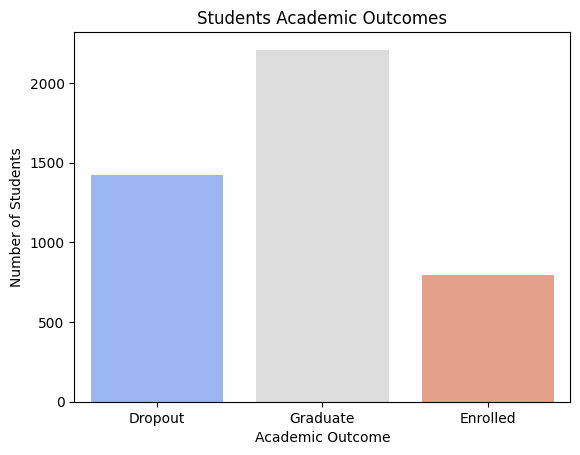

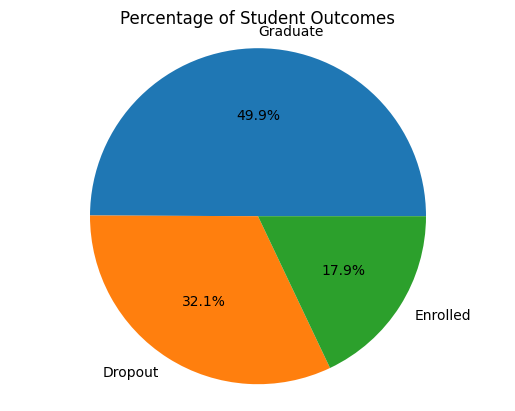

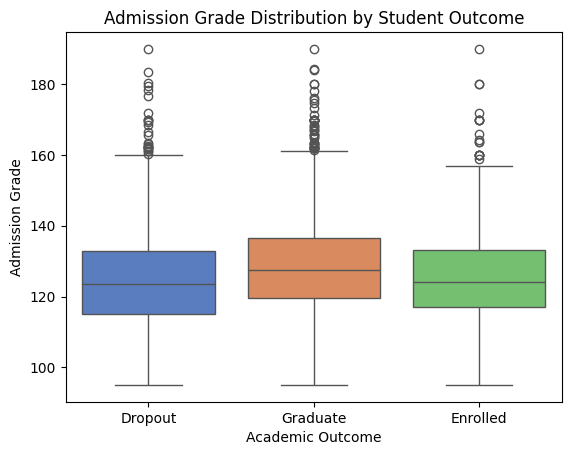

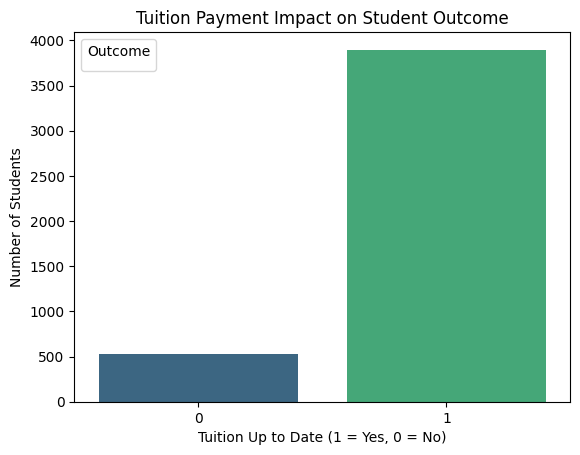

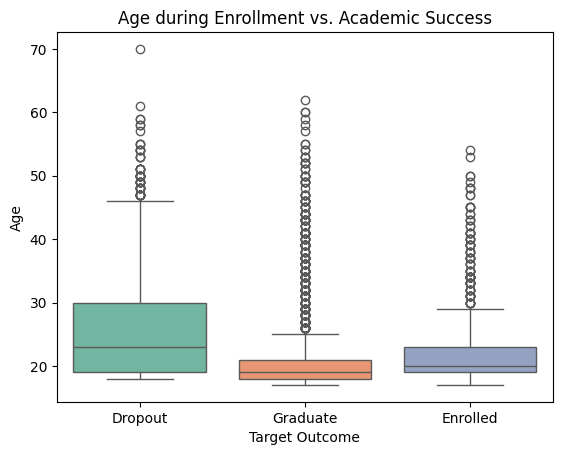

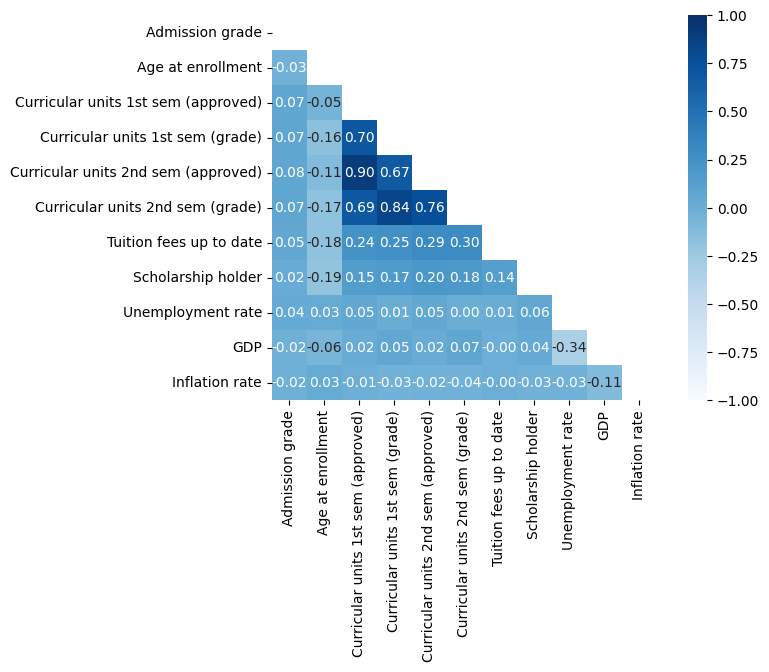

In [2]:
file_path = r"C:\Users\ediso\Downloads\New folder (2)\Dropout.csv"

#Load data
df = pd.read_csv(file_path)
print(df.head())

#General Plot
sns.countplot(data=df, x="target", palette="coolwarm")
plt.title("Students Academic Outcomes")
plt.xlabel("Academic Outcome")
plt.ylabel("Number of Students")
plt.show()

#Pie Chart
target_counts = df["target"].value_counts()
plt.pie(target_counts, labels=target_counts.index, autopct="%1.1f%%")
plt.title("Percentage of Student Outcomes")
plt.axis("equal") 
plt.show()

#Plots of Features vs Student's Outcome
sns.boxplot(data=df, x="target", y="Admission grade", palette="muted")
plt.title("Admission Grade Distribution by Student Outcome")
plt.xlabel("Academic Outcome")
plt.ylabel("Admission Grade")
plt.show()

sns.countplot(data=df, x="Tuition fees up to date", palette="viridis")
plt.title("Tuition Payment Impact on Student Outcome")
plt.xlabel("Tuition Up to Date (1 = Yes, 0 = No)")
plt.ylabel("Number of Students")
plt.legend(title="Outcome")
plt.show()

sns.boxplot(data=df, x="target", y="Age at enrollment", palette="Set2")
plt.title("Age during Enrollment vs. Academic Success")
plt.xlabel("Target Outcome")
plt.ylabel("Age")
plt.show()

#Correlation Matrix
cols = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Tuition fees up to date",
    "Scholarship holder",
    "Unemployment rate",
    "GDP",
    "Inflation rate"
]
plt.figure(figsize=(8,5))   
corr_matrix = df[cols].corr()
sns.heatmap(corr_matrix, cmap="Blues", vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, mask=np.triu(np.ones_like(corr_matrix, dtype=bool)))
plt.show()

# Data Analysis
To predict student outcomes, we train and evaluate three classifier models which are a decision tree, random forest, and the gradient boosting classifier. Before the training process, I've split the dataset in a 80/20 train/split. 

My first model was to construct a Decision Tree with a max depth of 4 and a balance class weights to cover for unequal amounts of students across the outcomes. The visualization of the tree is provided below, where individual nodes represent a decision based on a specific feature of the dataset, and each tree branch leads to a predicted outcome. 

My second model is a Random Forest Classifier that contains 100 individual decision trees. This method builds multiple decision trees and merges their results together to improve accuracy and reduce the  problems of overfitting seen in other models.

My final model is a Gradient Boosting Classifier with 100 estimators, a learning rate of 0.1, and a max tree depth of 4. Gradient Boosting builds each tree sequentially where every tree correcting previous errors which makes this a power method for classification that also reduces overfitting. 

After traning, I have added a confusion matrix where each methods' prediction is tracked across all three outcome classes. The diagonal values of each matrix represent correct predictions, whereas all the other inputed values represent misclassifications. In conclusion of the confusion matrices, we see that all models predict graduated students most accurately, while they struggle to predict enrolled students. I have then added in the confusion matrices accuracy percentage and we can see that the gradient boosting classifier model yields the highest accuracy, followed by a close second in the random forest model, which are both substantially more accurate than the decision tree model. 





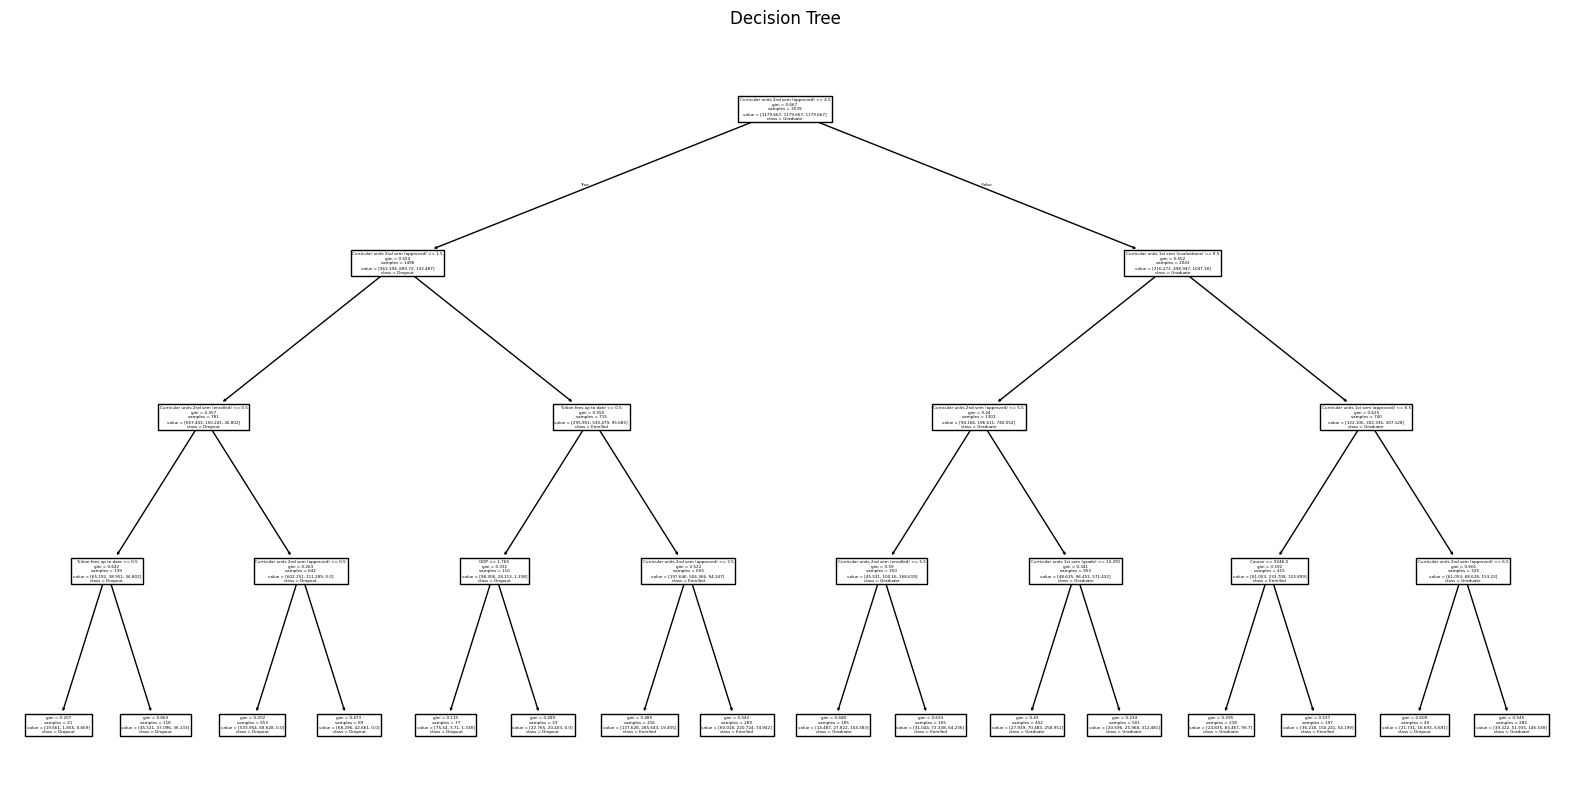

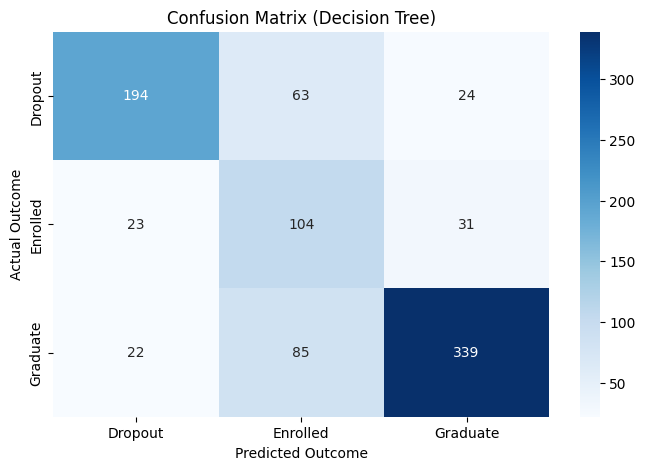

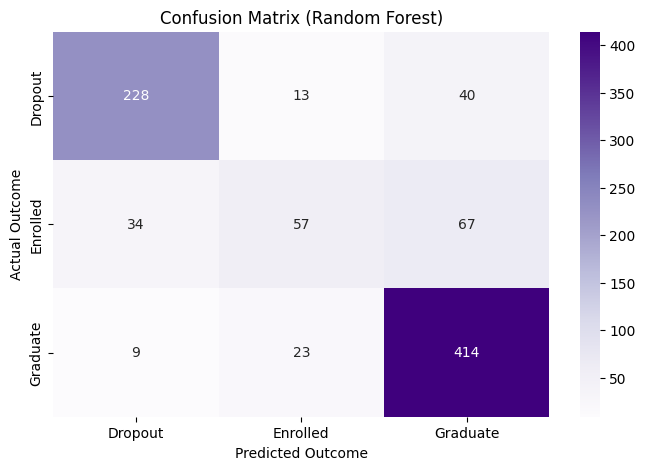

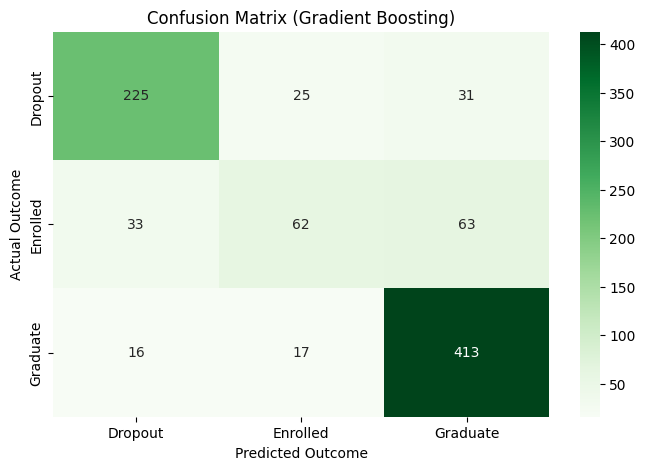

Decision Tree Accuracy: 0.7198
Random Forest Accuracy: 0.7898
Gradient Boosting Accuracy: 0.7910


In [3]:
#Handling Train/Test
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

#Decision Tree Model
model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_)
plt.title("Decision Tree")
plt.show()

#Random Forest Model
RF_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train,y_train)
RF_predictions = RF_model.predict(X_test)

#Gradient Boosting Model
boost_dropout = GradientBoostingClassifier(n_estimators = 100, 
                    learning_rate = 0.1,
                    max_depth = 3,
                    random_state = 42)
boost_dropout.fit(X_train, y_train)
y_pred = boost_dropout.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)

#Confusion Matrices
plt.figure(figsize=(8,5))   
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix (Decision Tree)")
plt.ylabel("Actual Outcome")
plt.xlabel("Predicted Outcome")
plt.show()

plt.figure(figsize=(8,5))   
cm = confusion_matrix(y_test, RF_predictions, labels=RF_model.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=RF_model.classes_, yticklabels=RF_model.classes_)
plt.title("Confusion Matrix (Random Forest)")
plt.ylabel("Actual Outcome")
plt.xlabel("Predicted Outcome")
plt.show()

plt.figure(figsize=(8,5))   
cm = confusion_matrix(y_test, y_pred, labels=boost_dropout.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=boost_dropout.classes_, yticklabels=boost_dropout.classes_)
plt.title("Confusion Matrix (Gradient Boosting)")
plt.ylabel("Actual Outcome")
plt.xlabel("Predicted Outcome")
plt.show()

#Accuracy Score
print(f"Decision Tree Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, RF_predictions):.4f}")
print(f"Gradient Boosting Accuracy: {accuracy:.4f}")

# Interpretation
We aim to understand the features that drive our prediction models to influence how institutions/government can solve the main issues behind the high dropout rate. The two plots below emphasis what's causing the dropout rates as it displays the top 10 most influential features into the two most accurate models. 

Through our Random Forest model we can see the features that are the most important are course units in their semesters that gotten approved, their grades, and how many exams they sat with all of these factors being roughly as important. We see that admission grades slightly trails those features as it comes in as the 6th most important.

For our Gradient Boosting model we see a stark difference compared to our Random Forest model as curricular units 2nd semester is ahead of all other features by a longshot as it has an importance feature of 0.5-0.6 while the second most important feature is tuition fees payment status with less than 0.1. 

In conclusion we can see how both of our models highlights an importance on the top signal (2nd semester unit approvals). Something to note is how the Gradient Boosting models has tuition fees status as a much stronger predictor than our Random Forest model. Otherwise both our models agree on the importance of other features equally such as the courses you're approved in, your grades, and the amount of exams you sat with all of these factors being low on the importance score, showing how they do contribute, but none of them stand out in our models. 



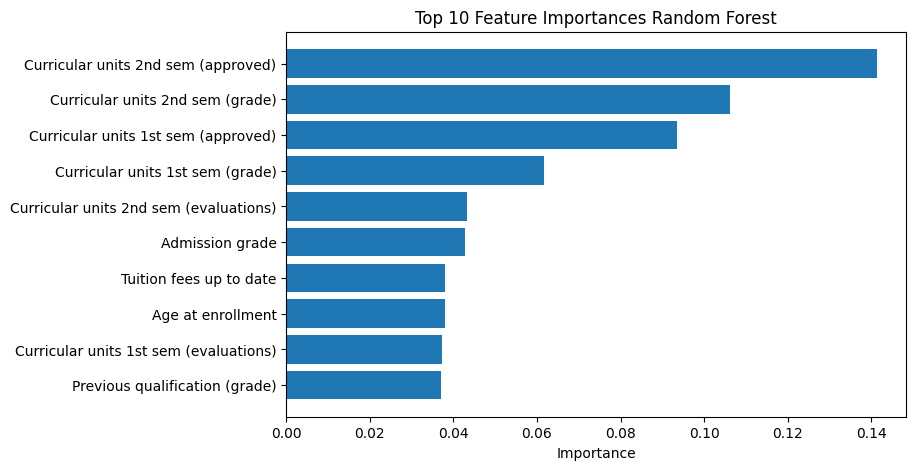

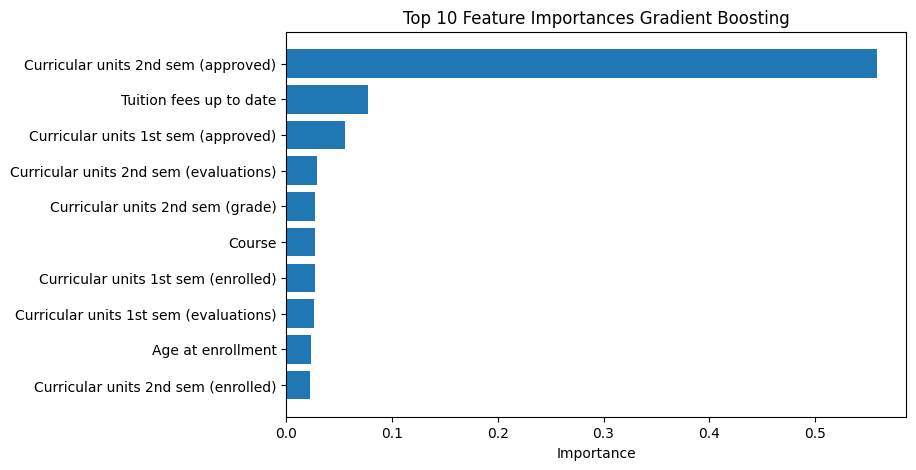

In [4]:
importances = RF_model.feature_importances_
plt.figure(figsize=(8, 5))
indices = np.argsort(importances)[-10:] 
plt.title("Top 10 Feature Importances Random Forest")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importance")
plt.show()

importances = boost_dropout.feature_importances_
plt.figure(figsize=(8, 5))
indices = np.argsort(importances)[-10:] 
plt.title("Top 10 Feature Importances Gradient Boosting")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importance")
plt.show()

# Conclusion
My project set out to identify key factors behind the high amount of post-secondary dropouts and to build classifiaction models that could predict academic outcomes. Using the provided dataset, I've applied three classification models and evaluated their performances to leverage conclusions. All of the models provided meaningful predictive analysis on the test set with the Gradient Boosting Classifier model and the Random Forest model being the most accurate.

The most significant part of my project came from the importance analysis as it provided us with the most important features that lead to students graduating or dropping out. My findings were that the student's trajectory of their academic future lies most upon how many course units students passed in their 2nd semester, this finding was consistent with both of my models. This conclusion is important because it suggests that a student's academic trajectory is largely apparent by the end of their second semester before any decision to dropout or continue enrollment leading us to use our model as inspiration as a means to predict students' success levels. The Gradient Boosting Classifier model also highlighted how tuition fee payment status is a strong predictor as well. 

Taking all this in account, these findings highlight clear and actionable steps that institutions can use to reduce the rate of dropouts. Through the monitoring of two key indicators (2nd semester credits and tuition payment status), universities can monitor at-risk students as soon as the end of the 2nd semester and deploy targeted interventions to offset students dropping out. These measures can range from mental health counselling, financial aid programs, extra tutoring, and flexible payment methods to aid students facing financial hardship. 

